# 17 &middot; Skinning Eigenmodes: a Subspace that Can Rotate

A high-resolution beam is accurate but slow (tutorial&nbsp;10): every Backward-Euler step solves a sparse system as large as the mesh. **Reduced-order modeling** restricts the motion to a small subspace, built once offline, and solves for its $r \ll n\,\text{dim}$ coordinates $z$ instead. We compare two bases, **linear modal analysis** (LMA) and **skinning eigenmodes**: we time the full solve, show that the subspace shrinks the solve but not the integration, watch a cantilever sag in each space, and rotate the rest shape a full turn to see which subspace can rotate.

$$x \;=\; B\,z + q, \qquad z\in\mathbb{R}^r,\quad r \ll n\,\text{dim}.$$

Imports, and every tunable parameter of this notebook.

In [1]:
%matplotlib inline
import os
import warnings
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import igl
import simkit
import utils

warnings.filterwarnings("ignore", category=sp.linalg.LinAlgWarning)   # stiff pin -> benign ill-conditioning
warnings.filterwarnings("ignore", message=".*encountered in matmul")   # spurious macOS-BLAS matmul warnings

NOTEBOOK = "017_skinning_eigenmodes"                               # this file's name
RESULTS_DIR = simkit.filesystem.notebook_results_path(NOTEBOOK)    # results/017_skinning_eigenmodes/
MEDIA_DIR = "media"                                                # tracked copies for the website
# beam meshes
WIDTH, HEIGHT = 4.0, 0.5            # beam size
NX_HI, NY_HI = 120, 30              # high-resolution grid of the timing study
NX, NY = 50, 11                     # grid of the dynamics and rotation studies
# material and loads
MATERIAL = "macklin-mueller-neo-hookean"
YM, PR = 3000.0, 0.4                # Young's modulus, Poisson ratio
RHO = 1.0                           # density
GRAVITY = -9.8                      # vertical gravitational acceleration
K_PIN = 1e7                         # soft-pin stiffness on the left wall
# Backward-Euler time stepping
DT = 2e-2                           # timestep
N_STEPS = 80                        # steps of the sag simulation
NEWTON_ITERS = 30                   # max Newton iterations per step (with line search)
# subspaces
K_MODES = 12                        # skinning eigenmodes (bones); LMA gets K_MODES or 6*K_MODES modes
WEIGHTS_SHOWN = [0, 1, 4, 8]        # skinning weight fields drawn
LMA_MODES_SHOWN = [2, 3, 4, 6]      # LMA mode shapes drawn
LMA_MODE_AMPLITUDE = 0.4            # largest vertex displacement when drawing a mode shape
# validation
FD_STEP = 1e-6                      # central-difference step of the gradient check
FD_NOISE = 0.01                     # random perturbation of the subspace coordinates for the check
SEED = 0                            # random seed (gradient check and timing pose)
# timing study
TIMING_NOISE = 0.005                # random vertex perturbation of the timed pose (below the edge length)
TIMING_MODE_COUNTS = [2, 5, 10, 20, 40]   # skinning eigenmode counts that are timed
TIMING_REPEATS = 5                  # timings report the best of this many batches
TIMING_INNER_SPARSE = 3             # calls per batch for the full sparse solve
TIMING_INNER_DENSE = 200            # calls per batch for the (sub-millisecond) dense subspace solve
# rotation study
N_ANGLES = 73                       # rest-shape rotations in [0, 360] deg (animation frames)
SWEEP_MODES = np.arange(1, 21)      # skinning eigenmode counts of the turn-averaged error sweep
N_ANGLES_SWEEP = 49                 # rotations averaged over in the sweep
# videos
FPS_DYN = 20                        # sag video
FPS_ROT = 18                        # rotation video
# colors
FULL_C = "#d62728"                  # full space (reference / "slow")
LMA_C = "#1f77b4"                   # LMA with 6*K_MODES modes (same DOFs as skinning)
LMA_SMALL_C = "#9ecae1"             # LMA with K_MODES modes
SKIN_C = "#2ca02c"                  # skinning eigenmodes

## Two beams

Both are $4 \times 0.5$ libigl grids with the left wall pinned (blue squares): a high-resolution one for the timing study and a coarser one for the dynamics and rotation studies. The orange dot is the bottom-right tip vertex whose height we track during the sag.

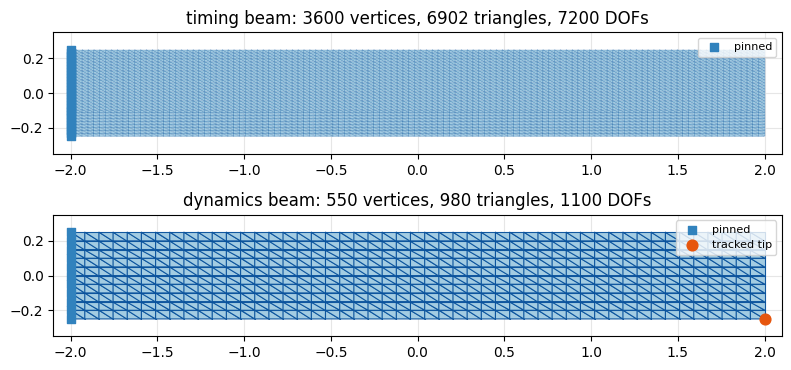

In [2]:
V_hi, T_hi = igl.triangulated_grid(NX_HI, NY_HI)       # unit square, NX_HI x NY_HI vertices
X_hi = (V_hi - 0.5) * np.array([WIDTH, HEIGHT])         # centered WIDTH x HEIGHT beam
V_grid, T = igl.triangulated_grid(NX, NY)
X = (V_grid - 0.5) * np.array([WIDTH, HEIGHT])
n, dim = X.shape
pin_hi = np.where(X_hi[:, 0] <= X_hi[:, 0].min() + 1e-6)[0]
pin_idx = np.where(X[:, 0] <= X[:, 0].min() + 1e-6)[0]
tip = int(np.argmax(X[:, 0]))                            # bottom-right corner

fig, axes = plt.subplots(2, 1, figsize=(11, 3.8))
utils.plot_mesh(axes[0], X_hi, T_hi, pins=pin_hi, lw=0.15,
                title=f"timing beam: {len(X_hi)} vertices, {len(T_hi)} triangles, {X_hi.size} DOFs")
utils.plot_mesh(axes[1], X, T, pins=pin_idx,
                title=f"dynamics beam: {n} vertices, {len(T)} triangles, {X.size} DOFs")
axes[1].scatter(*X[tip], s=60, color=utils.HANDLE_C, zorder=6, label="tracked tip")
axes[1].legend(loc="upper right", fontsize=8)
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "meshes.png"),
                              copy_to=os.path.join(MEDIA_DIR, "017_meshes.png"))
plt.show()

## Constant operators

`beam_operators` builds, once per mesh, everything the dynamics reuse: the deformation Jacobian `J`, triangle areas `vol`, Lamé parameters, the lumped mass matrix `M`, the gravity force `f_g` and the soft pin `(Q_pin, b_pin)` on the left wall. The figure shows the lumped vertex mass of the dynamics beam. It weights the inertia term and the mass norm $\lVert\cdot\rVert_M$ of every subspace projection below; boundary vertices carry less mass than interior ones.

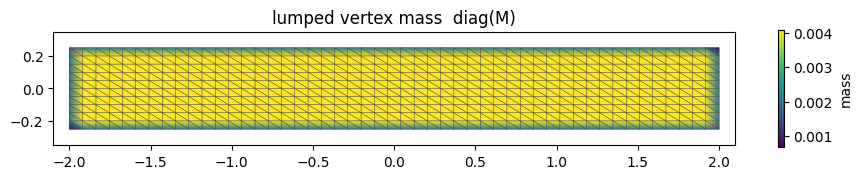

In [3]:
def beam_operators(X, T):
    """Constant operators of the pinned neo-Hookean beam, built once from simkit."""
    n, dim = X.shape
    mu_value, lam_value = simkit.ympr_to_lame(YM, PR)
    pin = np.where(X[:, 0] <= X[:, 0].min() + 1e-6)[0]
    Q_pin, b_pin = simkit.dirichlet_penalty(pin, X[pin], n, K_PIN)
    M_vertex = simkit.massmatrix(X, T, rho=RHO)                       # (n, n) lumped mass
    ops = {
        "n": n, "dim": dim,
        "J": simkit.deformation_jacobian(X, T),
        "vol": simkit.volume(X, T),
        "mu": np.full((len(T), 1), mu_value),
        "lam": np.full((len(T), 1), lam_value),
        "M": sp.sparse.kron(M_vertex, sp.sparse.eye(dim)).tocsc(),    # (n*dim, n*dim)
        "f_g": simkit.gravity_force(X, T, a=GRAVITY, rho=RHO).reshape(-1, 1),
        "Q_pin": Q_pin, "b_pin": b_pin,
    }
    return ops

ops_hi = beam_operators(X_hi, T_hi)
ops = beam_operators(X, T)

fig, ax = plt.subplots(figsize=(11, 1.9))
utils.plot_scalar_field(ax, X, T, ops["M"].diagonal()[::dim], title="lumped vertex mass  diag(M)",
                        label="mass")
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "vertex_mass.png"),
                              copy_to=os.path.join(MEDIA_DIR, "017_vertex_mass.png"))
plt.show()

## The system: one Backward-Euler step in a subspace

Each step minimizes the incremental potential below (momentum target $\tilde x = 2x_n - x_{n-1}$, neo-Hookean elasticity, gravity, wall pin). `subspace_beam_system` writes it in subspace coordinates $z$ with $x = Bz+q$: every term is evaluated on the **full** $x$ (full integration, no cubature), and the **Galerkin projection** $B^{\top}g$, $B^{\top}HB$ brings the gradient and Hessian down to $r$ coordinates. With $B=I$, $q=0$ it is the ordinary full-space step.

$$x_{n+1} = \arg\min_x \; \tfrac{1}{2h^2}\lVert x-\tilde x\rVert^2_M + \Psi_{\text{neo}}(x) - f_g^{\top}x + \tfrac12\lVert x_{\text{pin}}-X_{\text{pin}}\rVert^2_K .$$

In [4]:
def subspace_beam_system(ops, B, q, x_curr, x_prev):
    """Backward-Euler step of the pinned beam in subspace coordinates z, where x = B z + q."""
    n, dim = ops["n"], ops["dim"]
    J, vol, mu, lam = ops["J"], ops["vol"], ops["mu"], ops["lam"]
    M, f_g, Q_pin, b_pin = ops["M"], ops["f_g"], ops["Q_pin"], ops["b_pin"]

    def energy_func(z):
        x = B @ z + q
        E_inertia = simkit.energies.kinetic_energy_be(x, x_curr, x_prev, M, DT)
        E_elastic = simkit.energies.elastic_energy_x(x.reshape(n, dim), J, mu, lam, vol, MATERIAL)
        E_gravity = -(f_g.T @ x).item()
        E_pin = simkit.energies.quadratic_energy(x, Q_pin, b_pin)
        E_total = E_inertia + E_elastic + E_gravity + E_pin
        return E_total

    def gradient_func(z):
        x = B @ z + q
        g_inertia = simkit.energies.kinetic_gradient_be(x, x_curr, x_prev, M, DT)
        g_elastic = simkit.energies.elastic_gradient_x(x.reshape(n, dim), J, mu, lam, vol, MATERIAL)
        g_gravity = -f_g
        g_pin = simkit.energies.quadratic_gradient(x, Q_pin, b_pin)
        g_total = g_inertia + g_elastic + g_gravity + g_pin
        g_z = B.T @ g_total                                   # Galerkin projection
        return g_z

    def hessian_func(z):
        x = B @ z + q
        H_inertia = simkit.energies.kinetic_hessian_be(M, DT)
        H_elastic = simkit.energies.elastic_hessian_x(x.reshape(n, dim), J, mu, lam, vol, MATERIAL, psd=True)
        H_pin = simkit.energies.quadratic_hessian(Q_pin)
        H_total = H_inertia + H_elastic + H_pin
        H_z = B.T @ (H_total @ B)                             # Galerkin projection
        return H_z

    return energy_func, gradient_func, hessian_func

## Two subspaces, built once

Both bases come from the lowest eigenvectors of a mesh operator but use them differently. We build LMA with $6k$ modes (as many DOFs as skinning) and also keep its lowest $k$; the printout lists the basis sizes and the lowest eigenvalues.

* **LMA** (`simkit.linear_modal_analysis`): the lowest vibration modes are *displacement* columns, $x = X + B_{\text{lma}}z$, so $q = X$. A sum of fixed displacement fields is linear in $z$, and rotation is not.
* **Skinning eigenmodes** (`simkit.skinning_eigenmodes`): the lowest Laplacian eigenvectors are skinning **weights** $W$, each carrying a $2\times3$ affine transform, $x = B_{\text{skin}}z$ with $q = 0$. That is 6 DOFs per mode, and affine transforms contain rotation.

In [5]:
E_lma, B_lma = simkit.linear_modal_analysis(X, T, 6 * K_MODES)   # 6k displacement modes, lowest first
B_lma_small = B_lma[:, :K_MODES]                                 # the lowest k of them
W, E_skin, B_skin = simkit.skinning_eigenmodes(X, T, K_MODES)    # k weights -> 6k affine DOFs
q_lma = X.reshape(-1, 1)                                         # LMA: x = X + B z
q_skin = np.zeros((X.size, 1))                                   # skinning: x = B z
print(f"k = {K_MODES}")
print(f"  LMA  small basis: {B_lma_small.shape[1]:3d} columns  (k displacement modes)")
print(f"  LMA  basis      : {B_lma.shape[1]:3d} columns  (6k displacement modes)")
print(f"  skin basis      : {B_skin.shape[1]:3d} columns  (k weights x 6 affine DOFs)")
print(f"lowest LMA eigenvalues : {np.array2string(E_lma[:5], precision=3)}")
print(f"lowest skin eigenvalues: {np.array2string(E_skin[:3], precision=3)}")

k = 12
  LMA  small basis:  12 columns  (k displacement modes)
  LMA  basis      :  72 columns  (6k displacement modes)
  skin basis      :  72 columns  (k weights x 6 affine DOFs)
lowest LMA eigenvalues : [-1.009e-13 -3.836e-14  4.272e-14  1.026e-01  6.580e-01]
lowest skin eigenvalues: [2.243e-14 6.166e-01 2.464e+00]


The skinning weights are smooth Laplacian eigenvectors of increasing frequency. $W_0$ is constant (eigenvalue $0$): its affine bone moves the whole beam as one rigid or affine body, which is where exact rotation comes from.

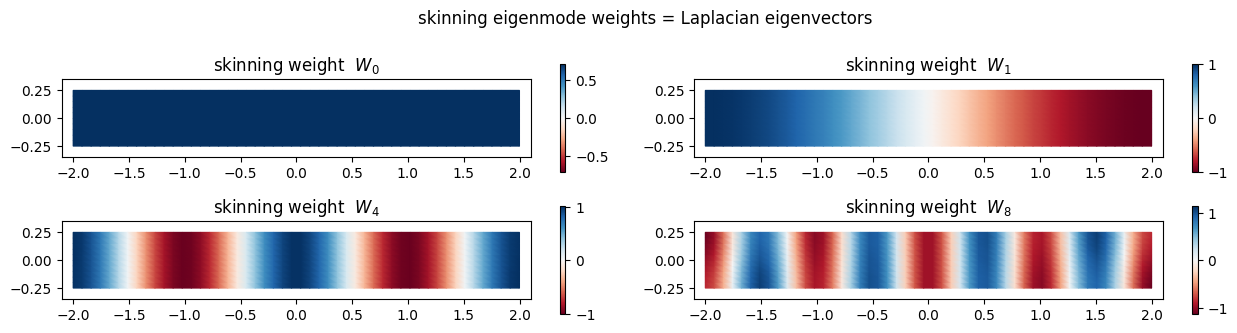

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 3.4))
for ax, j in zip(axes.ravel(), WEIGHTS_SHOWN):
    w_max = np.abs(W[:, j]).max()
    utils.plot_scalar_field(ax, X, T, W[:, j], cmap="RdBu", vmin=-w_max, vmax=w_max, edges=False,
                            title=f"skinning weight  $W_{{{j}}}$")
fig.suptitle("skinning eigenmode weights = Laplacian eigenvectors")
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "skinning_weights.png"),
                              copy_to=os.path.join(MEDIA_DIR, "017_skinning_weights.png"))
plt.show()

LMA columns are displacement fields instead. Below, the rest beam is displaced along a few of them and colored by displacement magnitude. The first three eigenvalues are $0$: they span the two translations and the **linearized** rotation $\delta x \propto (-y, x)$ (mode 2 here is a mix of them, rotating about a shifted center). The next modes bend the beam.

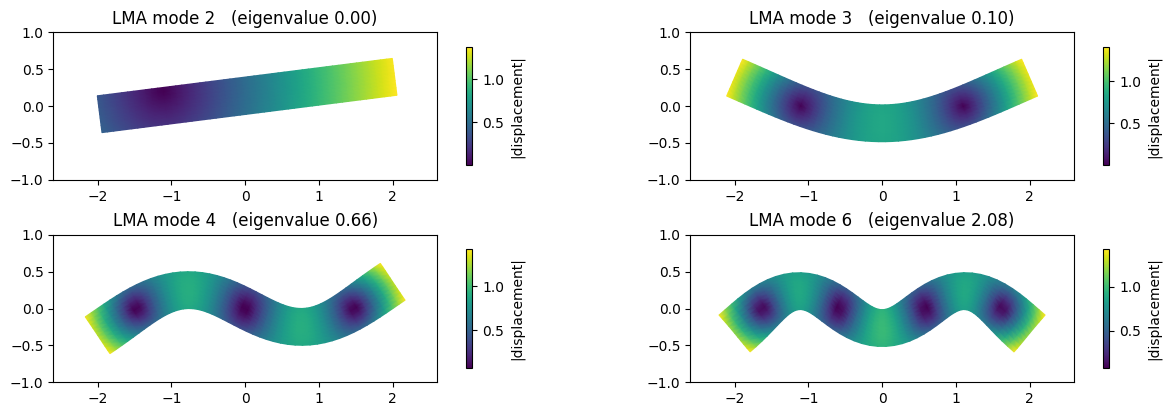

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 4.2))
for ax, j in zip(axes.ravel(), LMA_MODES_SHOWN):
    mode = B_lma[:, j].reshape(n, dim)
    magnitude = np.linalg.norm(mode, axis=1)
    U = X + LMA_MODE_AMPLITUDE / magnitude.max() * mode
    utils.plot_scalar_field(ax, U, T, magnitude, edges=False, label="|displacement|",
                            lims=((-2.6, 2.6), (-1.0, 1.0)),
                            title=f"LMA mode {j}   (eigenvalue {E_lma[j]:.2f})")
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "lma_modes.png"),
                              copy_to=os.path.join(MEDIA_DIR, "017_lma_modes.png"))
plt.show()

## Checking the system

Before timing anything, two cheap checks on the dynamics beam. The projected gradient $B^{\top}g$ in the skinning subspace matches a central finite difference of the energy (`simkit.gradient_cfd`) to about $10^{-9}$. On the first time step from rest, Newton cuts the gradient norm (in each space's own coordinates) by five to six orders of magnitude within two steps in every space; the skinning solve then idles at round-off, where the stiff pin meets a dense basis, until its step drops below the tolerance.

skinning subspace gradient vs finite differences: relative error 3.7e-09
  full                  : 3 Newton iterations
  LMA  72 modes         : 3 Newton iterations
  skinning  72 DOFs     : 6 Newton iterations


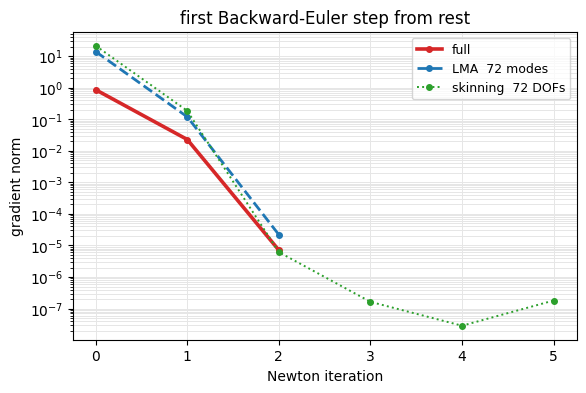

In [8]:
x_rest = X.reshape(-1, 1)
rng = np.random.default_rng(SEED)
z_rest_skin = simkit.project_into_subspace(x_rest - q_skin, B_skin, M=ops["M"])
z_check = z_rest_skin + FD_NOISE * rng.standard_normal(z_rest_skin.shape)
energy_func, gradient_func, _ = subspace_beam_system(ops, B_skin, q_skin, x_rest, x_rest)
g_fd = simkit.gradient_cfd(lambda z: np.array(energy_func(z)), z_check, FD_STEP)
g_an = gradient_func(z_check).ravel()
print(f"skinning subspace gradient vs finite differences: relative error "
      f"{np.linalg.norm(g_fd - g_an) / np.linalg.norm(g_an):.1e}")

spaces = {
    "full": (sp.sparse.identity(X.size, format="csc"), q_skin),
    f"LMA  {B_lma.shape[1]} modes": (B_lma, q_lma),
    f"skinning  {B_skin.shape[1]} DOFs": (B_skin, q_skin),
}
grad_norms = {}
for name, (B, q) in spaces.items():
    z0 = simkit.project_into_subspace(x_rest - q, B, M=ops["M"])
    step_funcs = subspace_beam_system(ops, B, q, x_rest, x_rest)
    _, info = simkit.solvers.newton_solver(z0, *step_funcs, max_iter=NEWTON_ITERS,
                                           do_line_search=True, return_info=True)
    grad_norms[name] = [np.linalg.norm(g) for g in info["g"]]
    print(f"  {name:22s}: {info['iters'] + 1} Newton iterations")

fig, ax = utils.residual_plot(grad_norms, colors=dict(zip(spaces, [FULL_C, LMA_C, SKIN_C])),
                              markers=True, xlabel="Newton iteration", ylabel="gradient norm",
                              title="first Backward-Euler step from rest", figsize=(6.5, 4))
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "newton_convergence.png"),
                              copy_to=os.path.join(MEDIA_DIR, "017_newton_convergence.png"))
plt.show()

## The full solve is slow

On the high-resolution beam we build the full-space system at a slightly perturbed pose (zero velocity) and time its two halves: **evaluation** (gradient and Hessian assembly) and the sparse **linear solve**. `utils.best_time` reports the best of several batches of calls.

In [9]:
x_rest_hi = X_hi.reshape(-1, 1)
q_zero_hi = np.zeros((X_hi.size, 1))
x_def = x_rest_hi + TIMING_NOISE * rng.standard_normal(x_rest_hi.shape)
_, gradient_full, hessian_full = subspace_beam_system(ops_hi, sp.sparse.identity(X_hi.size, format="csc"),
                                                      q_zero_hi, x_rest_hi, x_rest_hi)

def evaluate_full():
    return hessian_full(x_def), gradient_full(x_def)

H_full, g_full = evaluate_full()
H_full = H_full.tocsc()
t_eval_full = utils.best_time(evaluate_full, rep=TIMING_REPEATS)
t_solve_full = utils.best_time(lambda: sp.sparse.linalg.spsolve(H_full, -g_full), inner=TIMING_INNER_SPARSE,
                              rep=TIMING_REPEATS)
print(f"high-res beam: {X_hi.size} DOFs")
print(f"full-space eval (grad+Hess): {t_eval_full * 1e3:7.1f} ms")
print(f"full-space linear solve    : {t_solve_full * 1e3:7.1f} ms")

high-res beam: 7200 DOFs
full-space eval (grad+Hess):    27.1 ms
full-space linear solve    :    12.7 ms


## The subspace shrinks the *solve*, not the *integration*

We now build skinning subspaces with more and more eigenmodes on the same beam and time the same two halves. With full integration the subspace system still evaluates the neo-Hookean energy on every triangle and then projects, so **Plot 2** (evaluation) stays at the full-space cost. What collapses is the solve, from a sparse $n\,\text{dim}\times n\,\text{dim}$ system to a tiny dense $r\times r$ one (**Plot 1**, log scale, full solve in red).

  skinning k= 2 (r= 12): solve  0.00282 ms   eval   26.1 ms


  skinning k= 5 (r= 30): solve  0.00561 ms   eval   24.9 ms


  skinning k=10 (r= 60): solve  0.01567 ms   eval   25.3 ms


  skinning k=20 (r=120): solve  0.04885 ms   eval   28.3 ms


  skinning k=40 (r=240): solve  0.17792 ms   eval   30.2 ms


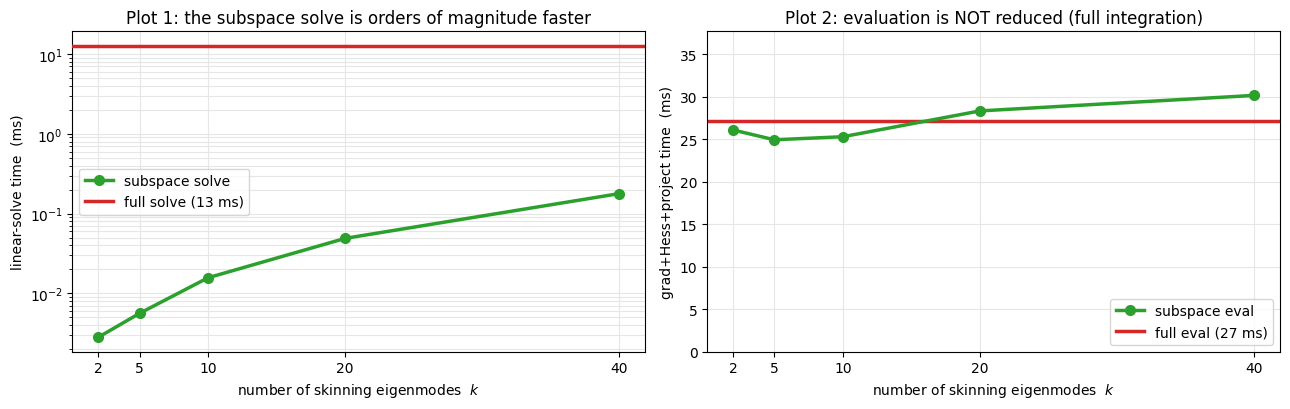

In [10]:
solve_sub, eval_sub = [], []
for k in TIMING_MODE_COUNTS:
    _, _, B_k = simkit.skinning_eigenmodes(X_hi, T_hi, k)
    z_def = simkit.project_into_subspace(x_def, B_k, M=ops_hi["M"])
    _, gradient_sub, hessian_sub = subspace_beam_system(ops_hi, B_k, q_zero_hi, x_rest_hi, x_rest_hi)

    def evaluate_sub():
        return hessian_sub(z_def), gradient_sub(z_def)

    H_z, g_z = evaluate_sub()
    eval_sub.append(utils.best_time(evaluate_sub, rep=TIMING_REPEATS) * 1e3)
    solve_sub.append(utils.best_time(lambda: np.linalg.solve(H_z, -g_z), inner=TIMING_INNER_DENSE,
                                     rep=TIMING_REPEATS) * 1e3)
    print(f"  skinning k={k:2d} (r={B_k.shape[1]:3d}): solve {solve_sub[-1]:8.5f} ms   eval {eval_sub[-1]:6.1f} ms")

mc = np.array(TIMING_MODE_COUNTS)
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.2))
axL.plot(mc, solve_sub, "-o", color=SKIN_C, lw=2.5, ms=7, label="subspace solve", zorder=3)
axL.axhline(t_solve_full * 1e3, color=FULL_C, lw=2.5, zorder=4, label=f"full solve ({t_solve_full * 1e3:.0f} ms)")
axL.set_yscale("log"); axL.set_xticks(mc)
axL.set_xlabel("number of skinning eigenmodes  $k$"); axL.set_ylabel("linear-solve time  (ms)")
axL.set_title("Plot 1: the subspace solve is orders of magnitude faster")
axL.legend(loc="center left"); axL.grid(True, which="both", color="0.9")
axR.plot(mc, eval_sub, "-o", color=SKIN_C, lw=2.5, ms=7, label="subspace eval", zorder=3)
axR.axhline(t_eval_full * 1e3, color=FULL_C, lw=2.5, label=f"full eval ({t_eval_full * 1e3:.0f} ms)")
axR.set_xticks(mc); axR.set_ylim(0, max(t_eval_full * 1e3, max(eval_sub)) * 1.25)
axR.set_xlabel("number of skinning eigenmodes  $k$"); axR.set_ylabel("grad+Hess+project time  (ms)")
axR.set_title("Plot 2: evaluation is NOT reduced (full integration)")
axR.legend(loc="lower right"); axR.grid(True, color="0.9")
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "timing.png"),
                              copy_to=os.path.join(MEDIA_DIR, "017_timing.png"))
plt.show()

## Fast solve, but does it look right?

Cost is only half the story. `simulate` drops the dynamics beam from rest under gravity, one `subspace_beam_system` Newton solve per step, and we run it in four spaces: full ($B=I$), LMA with $k$ and with $6k$ modes, and skinning with $k$ modes ($6k$ DOFs). The printout compares the final tip heights.

In [11]:
def simulate(ops, B, q):
    """Drop the beam from rest for N_STEPS Backward-Euler steps in the subspace x = B z + q."""
    z = simkit.project_into_subspace(x_rest - q, B, M=ops["M"])      # rest pose in subspace coordinates
    z_prev = z.copy()
    states = [(B @ z + q).reshape(n, dim)]
    for _ in range(N_STEPS):
        energy_func, gradient_func, hessian_func = subspace_beam_system(ops, B, q, B @ z + q, B @ z_prev + q)
        z_next = simkit.solvers.newton_solver(z, energy_func, gradient_func, hessian_func,
                                              max_iter=NEWTON_ITERS, do_line_search=True)
        z_prev, z = z, z_next
        states.append((B @ z + q).reshape(n, dim))
    return np.array(states)

runs = {
    f"full  ({X.size} DOFs)": (sp.sparse.identity(X.size, format="csc"), q_skin),
    f"LMA  ({B_lma_small.shape[1]} DOFs)": (B_lma_small, q_lma),
    f"LMA  ({B_lma.shape[1]} DOFs)": (B_lma, q_lma),
    f"skinning  ({B_skin.shape[1]} DOFs)": (B_skin, q_skin),
}
run_colors = dict(zip(runs, [FULL_C, LMA_SMALL_C, LMA_C, SKIN_C]))
states = {name: simulate(ops, B, q) for name, (B, q) in runs.items()}
tip_y = {name: S[:, tip, 1] for name, S in states.items()}
tip_full = tip_y[next(iter(runs))][-1]
for name, ys in tip_y.items():
    print(f"{name:22s}: final tip height {ys[-1]:+.2f}  ({ys[-1] / tip_full * 100:3.0f}% of the full droop)")

full  (1100 DOFs)     : final tip height -3.47  (100% of the full droop)
LMA  (12 DOFs)        : final tip height -0.56  ( 16% of the full droop)
LMA  (72 DOFs)        : final tip height -1.27  ( 37% of the full droop)
skinning  (72 DOFs)   : final tip height -2.99  ( 86% of the full droop)


Played side by side, the full beam swings its free end down through a large angle. Both LMA subspaces stall far above it (16% and 37% of the full droop), even with as many DOFs as skinning, because each LMA column is a fixed displacement and a large rotation is not a sum of them. Skinning rotates and tracks the full reference (86% of its droop).

In [12]:
panels = [{"states": S, "T": T, "title": name} for name, S in states.items()]
fig, anim = utils.animate_meshes_grid(panels, lims=((-2.5, 2.5), (-4.2, 0.6)), fps=FPS_DYN, figsize=(17, 4.3),
                                      suptitle="same sag in four spaces: LMA stalls, skinning tracks the full beam")
video = simkit.filesystem.save_animation(anim, os.path.join(RESULTS_DIR, "dynamics.mp4"), fps=FPS_DYN,
                                         copy_to=os.path.join(MEDIA_DIR, "017_dynamics.mp4"))
plt.close(fig)
utils.embed_video(video)

Two validation views of the same runs: the tip height over time, and the area ratio $\det F$ of every triangle in the final frame, drawn on the rest beam (red = stretched, blue = compressed). Skinning reproduces the full beam's pattern, a stretched top and a compressed bottom near the wall. The LMA beams barely bend, so they barely strain.

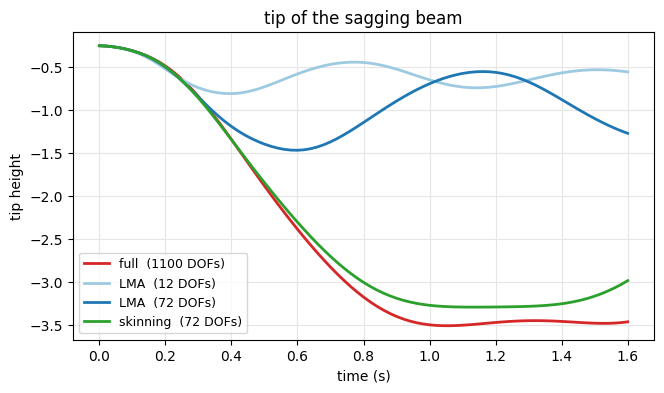

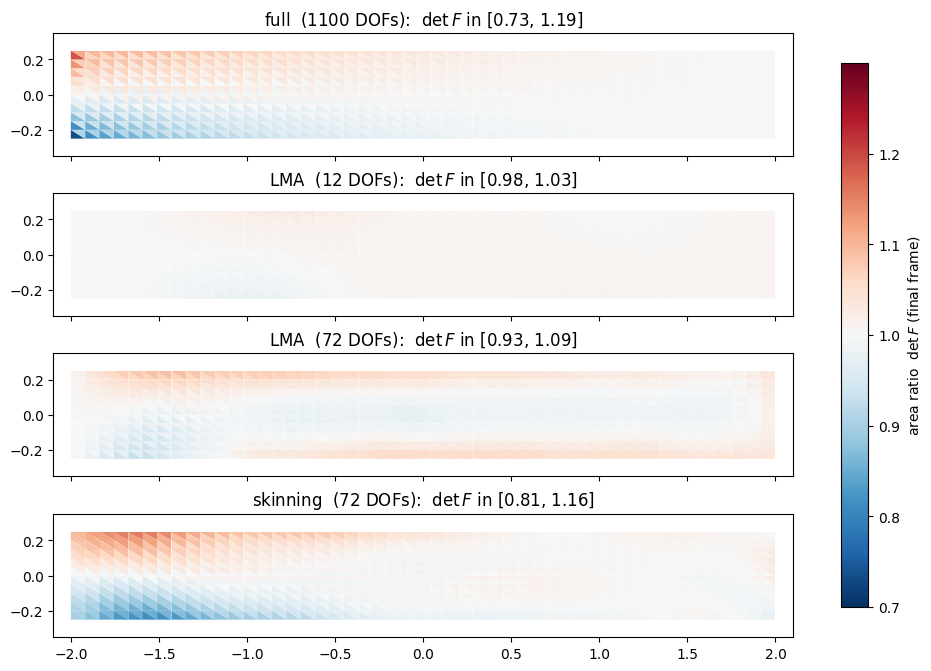

In [13]:
times = DT * np.arange(N_STEPS + 1)
fig, ax = utils.line_plot(times, tip_y, colors=run_colors, xlabel="time (s)", ylabel="tip height",
                          title="tip of the sagging beam", figsize=(7.5, 4))
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "tip_height.png"),
                              copy_to=os.path.join(MEDIA_DIR, "017_tip_height.png"))
plt.show()

area_ratio = {name: np.linalg.det((ops["J"] @ S[-1].reshape(-1, 1)).reshape(-1, dim, dim))
              for name, S in states.items()}
norm = TwoSlopeNorm(vmin=0.7, vcenter=1.0, vmax=1.3)
fig, axes = plt.subplots(4, 1, figsize=(11, 6.6), sharex=True, layout="constrained")
for ax, (name, S) in zip(axes, states.items()):
    m = utils.plot_scalar_field(ax, X, T, area_ratio[name], cmap="RdBu_r", norm=norm, edges=False, colorbar=False,
                                title=f"{name}:  $\\det F$ in [{area_ratio[name].min():.2f}, {area_ratio[name].max():.2f}]")
fig.colorbar(m, ax=axes.tolist(), shrink=0.9, label="area ratio  $\\det F$ (final frame)")
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "area_ratio.png"),
                              copy_to=os.path.join(MEDIA_DIR, "017_area_ratio.png"))
plt.show()

## The decisive test: rotate the rest shape a full turn

Take the rest beam, rotate it by $\theta$ through $360^\circ$, and ask each subspace to **reproduce** that rigid motion: project the rotated mesh $x_\theta$ into the subspace in the mass norm (`simkit.project_into_subspace`), reconstruct $Bz+q$, and measure the relative error $\lVert Bz+q - x_\theta\rVert_M / \lVert x_\theta\rVert_M$. `fit_poses` does exactly this for a list of target poses.

In [14]:
def fit_poses(B, q, targets):
    """Best mass-norm fit B z + q of each target pose, and its relative mass-norm error."""
    M = ops["M"]
    BMB = B.T @ (M @ B)                                       # reused by every projection
    fits, errors = [], []
    for y in targets:
        z = simkit.project_into_subspace(y - q, B, M=M, BMB=BMB)
        fit = B @ z + q
        d = fit - y
        errors.append(np.sqrt((d.T @ M @ d).item() / (y.T @ M @ y).item()))
        fits.append(fit.reshape(n, dim))
    return fits, np.array(errors)

def rotated_rest(angles_deg):
    """The rest beam rotated about its center by each angle, as stacked columns."""
    poses = []
    for th in np.deg2rad(angles_deg):
        R = np.array([[np.cos(th), -np.sin(th)], [np.sin(th), np.cos(th)]])
        poses.append((X @ R.T).reshape(-1, 1))
    return poses

angles = np.linspace(0, 360, N_ANGLES)
targets = rotated_rest(angles)
fits_lma_small, err_lma_small = fit_poses(B_lma_small, q_lma, targets)
fits_lma, err_lma = fit_poses(B_lma, q_lma, targets)
fits_skin, err_skin = fit_poses(B_skin, q_skin, targets)
i_peak = int(np.argmax(err_lma))
print(f"LMA  ({B_lma_small.shape[1]:2d} DOFs) error: 0 -> {err_lma_small.max():.3f} (peak at {angles[np.argmax(err_lma_small)]:.0f} deg) -> 0")
print(f"LMA  ({B_lma.shape[1]:2d} DOFs) error: 0 -> {err_lma.max():.3f} (peak at {angles[i_peak]:.0f} deg) -> 0")
print(f"skin ({B_skin.shape[1]:2d} DOFs) error: max {err_skin.max():.1e} over all angles")

LMA  (12 DOFs) error: 0 -> 0.342 (peak at 180 deg) -> 0
LMA  (72 DOFs) error: 0 -> 0.055 (peak at 180 deg) -> 0
skin (72 DOFs) error: max 8.5e-10 over all angles


A rotation is rigid (no strain, the cheapest thing a body can do), yet LMA cannot represent it. Its span contains the linearized rotation exactly, but a finite one, $(R_\theta - I)X = \sin\theta\,(-y, x) + (\cos\theta - 1)\,X$, also needs the uniform-scaling field $X$, which low-frequency modes capture only partly. The error is therefore $1-\cos\theta$ times the missing part of $X$ and peaks upside-down, where the LMA reconstructions (blue, target ghosted in gray) shrink and warp the beam; $6k$ modes only lower the peak. Skinning carries a rotation in every bone's affine block and matches the target at every angle, at round-off level. The still saved to `media/` is the $180^\circ$ frame.

In [15]:
ghosts = [y.reshape(n, dim) for y in targets]
fits = {f"LMA ({B_lma_small.shape[1]} DOFs)": (fits_lma_small, err_lma_small, LMA_C),
        f"LMA ({B_lma.shape[1]} DOFs)": (fits_lma, err_lma, LMA_C),
        f"skinning ({B_skin.shape[1]} DOFs)": (fits_skin, err_skin, SKIN_C)}
rot_panels = [{"states": F, "T": T, "ghost": ghosts, "color": c, "title": f"{name} reconstruction",
               "label": name, "ghost_label": "target (rotated rest)"} for name, (F, _, c) in fits.items()]
fig, anim = utils.animate_meshes_trace(
    rot_panels, angles, {name: err for name, (_, err, _) in fits.items()},
    colors=dict(zip(fits, [LMA_SMALL_C, LMA_C, SKIN_C])), lims=((-3.0, 3.0), (-3.0, 3.0)),
    xlabel="rest-shape rotation  (deg)", ylabel="reconstruction error  (mass norm)",
    trace_title="LMA error peaks upside-down", fps=FPS_ROT, figsize=(19, 4.6))
video = simkit.filesystem.save_animation(anim, os.path.join(RESULTS_DIR, "rotation_error.mp4"), fps=FPS_ROT,
                                         copy_to=os.path.join(MEDIA_DIR, "017_rotation_error.mp4"))
anim.set_frame(i_peak)
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "rotation_error.png"),
                              copy_to=os.path.join(MEDIA_DIR, "017_rotation_error.png"))
plt.close(fig)
utils.embed_video(video)

## Does adding modes fix it? Average the error over a full turn

The curves above are for fixed bases. For each of 20 subspace sizes ($k$ skinning modes against $6k$ LMA modes, the same DOFs) we average the reconstruction error over a full $360^\circ$ turn. More modes let LMA chase the rotation a little better, but a linear basis never contains it, so its error plateaus far from zero. Skinning is exact at every size, even with a single bone (6 DOFs); its tiny error only grows with the conditioning of the larger bases.

LMA : up to 120 DOFs -> turn-averaged error plateaus at 0.024
skin: up to 120 DOFs -> turn-averaged error at most 2.5e-08


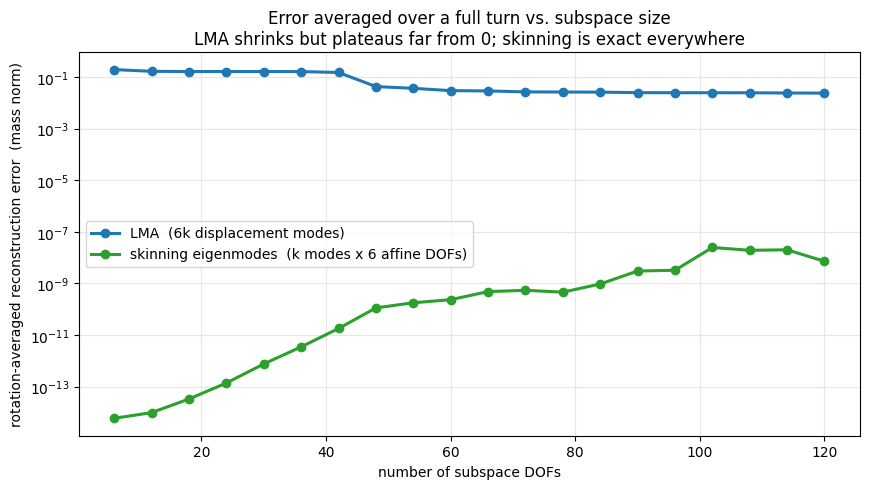

In [16]:
sweep_targets = rotated_rest(np.linspace(0, 360, N_ANGLES_SWEEP))
dofs, turn_err_lma, turn_err_skin = [], [], []
for k in SWEEP_MODES:
    _, B_lma_k = simkit.linear_modal_analysis(X, T, 6 * k)
    _, _, B_skin_k = simkit.skinning_eigenmodes(X, T, k)
    dofs.append(B_skin_k.shape[1])
    turn_err_lma.append(fit_poses(B_lma_k, q_lma, sweep_targets)[1].mean())
    turn_err_skin.append(fit_poses(B_skin_k, q_skin, sweep_targets)[1].mean())
print(f"LMA : up to {dofs[-1]:3d} DOFs -> turn-averaged error plateaus at {min(turn_err_lma):.3f}")
print(f"skin: up to {dofs[-1]:3d} DOFs -> turn-averaged error at most {max(turn_err_skin):.1e}")

fig, ax = plt.subplots(figsize=(8.8, 5.0))
ax.plot(dofs, turn_err_lma, "-o", color=LMA_C, lw=2.2, ms=6, label="LMA  (6k displacement modes)")
ax.plot(dofs, turn_err_skin, "-o", color=SKIN_C, lw=2.2, ms=6, label="skinning eigenmodes  (k modes x 6 affine DOFs)")
ax.set_yscale("log")
ax.set_xlabel("number of subspace DOFs"); ax.set_ylabel("rotation-averaged reconstruction error  (mass norm)")
ax.set_title("Error averaged over a full turn vs. subspace size\nLMA shrinks but plateaus far from 0; skinning is exact everywhere")
ax.grid(True, which="both", color="0.9"); ax.legend(loc="center left")
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "integrated_error.png"),
                              copy_to=os.path.join(MEDIA_DIR, "017_integrated_error.png"))
plt.show()

### Takeaways

* A subspace $x=Bz+q$ replaces an $n\,\text{dim}$-DOF solve with an $r$-DOF one. With full integration the gradient and Hessian still cost a full assembly: the subspace shrinks the **linear solve**, the part that explodes with resolution.
* **LMA** is a sum of fixed displacement fields, linear in $z$. Rotation lies outside it: the error of a rotated rest shape peaks at $180^\circ$, and in dynamics the free end refuses to swing, whatever the number of modes.
* **Skinning eigenmodes** attach an affine transform (which contains rotation) to each Laplacian-eigenvector weight, so they reproduce rigid rotation at every angle and track the full-order sag.
* Rule of thumb: if the motion rotates (cantilevers, tails, characters), use a **rotation-aware** subspace such as skinning eigenmodes.